# Review data
Plot all relevant time-series data collected for a visual comparison.

In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path


# Set directory paths
CODE_DIR = Path(os.path.abspath('')).resolve()
if CODE_DIR.name != 'Code' and (CODE_DIR / 'Code').exists():
    CODE_DIR = CODE_DIR / 'Code'
DATA_DIR = CODE_DIR.parent / 'Data' if CODE_DIR.name == 'Code' else CODE_DIR / 'Data'
RESULTS_DIR = CODE_DIR.parent / 'Results'
SUMMARIES_DIR = RESULTS_DIR / 'Summaries'

# Plot style
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['figure.dpi'] = 130

In [206]:
# Define information of each quarterly metric for plotting
metric_configs = [
    {
        'col': 'revenue (USD)',
        'title': '1. Revenue (USD)',
        'color': '#08519c',
        'type': 'currency_b',
    },
    {
        'col': 'revenue_qoq (%)',
        'title': '2. Revenue QoQ Growth Rate (%)',
        'color': '#3182bd',
        'type': 'pct',
    },
    {
        'col': 'revenue_yoy (%)',
        'title': '3. Revenue YoY Growth Rate (%)',
        'color': '#6baed6',
        'type': 'pct',
    },
    {
        'col': 'rpo (USD)',
        'title': '4. Remaining Performance Obligations (RPO) (USD)',
        'color': '#a63603',
        'type': 'currency_b',
    },
    {
        'col': 'rpo_qoq (%)',
        'title': '5. RPO QoQ Growth Rate (%)',
        'color': '#e6550d',
        'type': 'pct',
    },
    {
        'col': 'rpo_yoy (%)',
        'title': '6. RPO YoY Growth Rate (%)',
        'color': '#fd8d3c',
        'type': 'pct',
    },
    {
        'col': 'billings (USD)',
        'title': '7. Calculated Billings (USD)',
        'color': '#006d2c',
        'type': 'currency_b',
    },
    {
        'col': 'billings_qoq (%)',
        'title': '8. Billings QoQ Growth Rate (%)',
        'color': '#31a354',
        'type': 'pct',
    },
    {
        'col': 'billings_yoy (%)',
        'title': '9. Billings YoY Growth Rate (%)',
        'color': '#74c476',
        'type': 'pct',
    },
    {
        'col': 'large_customer_count',
        'title': '10. Number of Large Customers (ARR >= $100k)',
        'color': '#54278f',
        'type': 'count',
    },
    {
        'col': 'large_customer_qoq (%)',
        'title': '11. Large Customer QoQ Growth Rate (%)',
        'color': '#756bb1',
        'type': 'pct',
    },
    {
        'col': 'large_customer_yoy (%)',
        'title': '12. Large Customer YoY Growth Rate (%)',
        'color': '#9e9ac8',
        'type': 'pct',
    },
    {
        'col': 'net_revenue_retention (%)',
        'title': '13. Net Revenue Retention (%)',
        'color': '#cb181d',
        'type': 'pct',
    },
]

## Create DataFrame from CSVs

In [198]:
csv_path = DATA_DIR / 'qtrly_metrics.csv'
if not csv_path.exists():
    csv_path = Path('../Data/qtrly_metrics.csv')

df_metrics = pd.read_csv(csv_path)
df_metrics['timestamp_utc'] = pd.to_datetime(df_metrics['timestamp_utc'])
df_metrics = df_metrics.set_index('timestamp_utc').sort_index()
print(f"Loaded {len(df_metrics)} rows from qtrly_metrics.csv.")

Loaded 30 rows from qtrly_metrics.csv.


In [199]:
# NASDAQ:PYPL prices and returns
s_pypl_returns = pd.read_csv(
    DATA_DIR / 'pypl_returns.csv', 
    parse_dates=['timestamp_utc']
).set_index('timestamp_utc')['return'].dropna().sort_index()

# Cloud tech-related news headlines 
s_tech_headlines = pd.read_csv(
    DATA_DIR / 'tech_headlines.csv', 
    parse_dates=['timestamp_utc']
).set_index('timestamp_utc')['news_score'].dropna().sort_index()

# Datadog product releases
s_announcements = pd.read_csv(
    DATA_DIR / 'announcements.csv', 
    parse_dates=['timestamp_utc']
)
s_announcements = s_announcements[s_announcements['product_release'] == True].set_index('timestamp_utc')['product_release'].sort_index()
print("Created all pandas.Series for data analysis.")


Created all pandas.Series for data analysis.


## All 13 Quarterly Metrics vs. Time

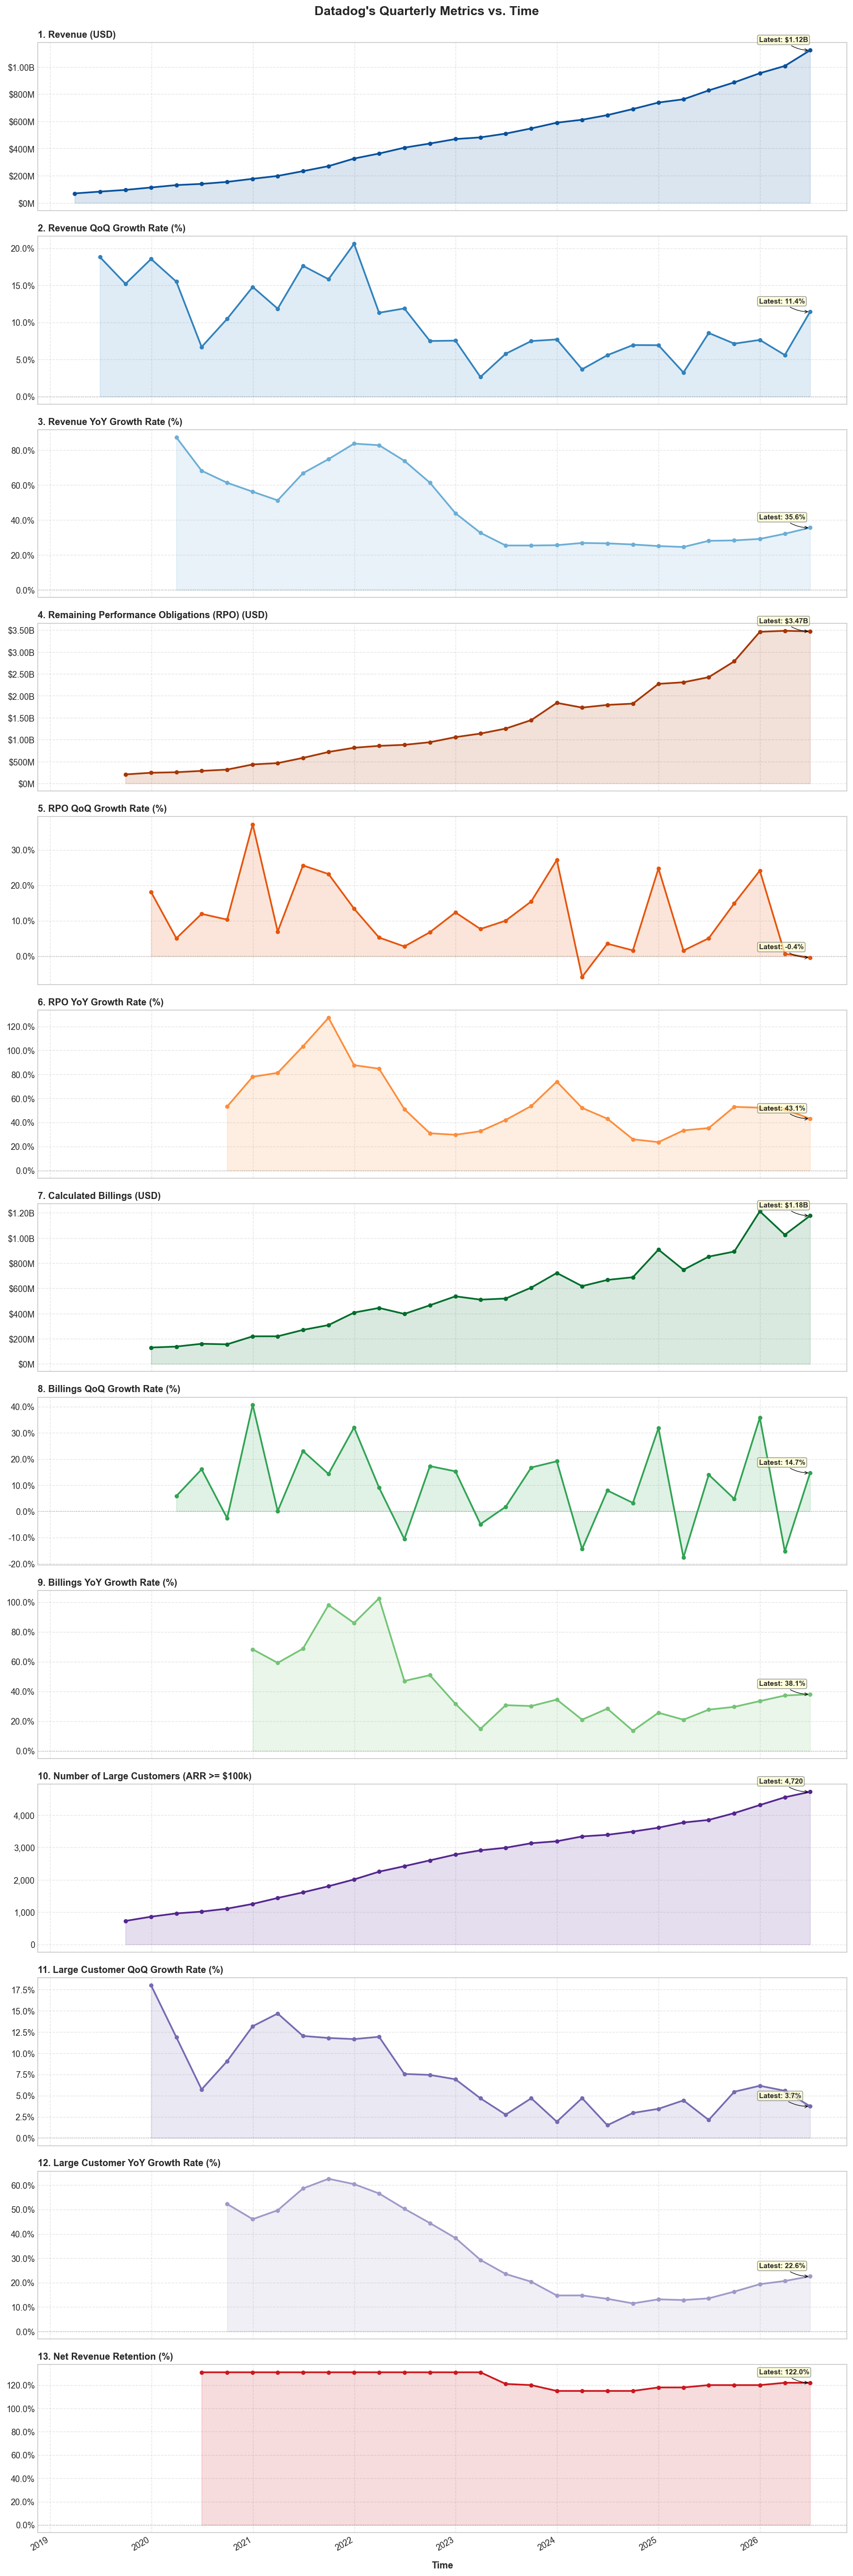

In [174]:
# Create 13 vertically stacked subplots
fig, axes = plt.subplots(len(metric_configs), 1, figsize=(14, 42), sharex=True)

for idx, cfg in enumerate(metric_configs):
    ax = axes[idx]
    col = cfg['col']
    
    if col in df_metrics.columns:
        series = df_metrics[col].dropna()
        dates = series.index
        values = series.values
        
        # Scaling & Formatting
        if cfg['type'] == 'currency_b':
            plot_values = values / 1e9
            formatter = ticker.FuncFormatter(lambda x, pos: f'${x:.2f}B' if x >= 1 else f'${x*1000:.0f}M')
        elif cfg['type'] == 'pct':
            plot_values = values
            formatter = ticker.FuncFormatter(lambda x, pos: f'{x:.1f}%')
        elif cfg['type'] == 'count':
            plot_values = values
            formatter = ticker.FuncFormatter(lambda x, pos: f'{int(x):,}')
        else:
            plot_values = values
            formatter = None

        # Plot line + fill
        ax.plot(dates, plot_values, marker='o', markersize=4, linewidth=2, color=cfg['color'], label=cfg['title'])
        ax.fill_between(dates, plot_values, alpha=0.15, color=cfg['color'])
        
        ax.set_title(cfg['title'], fontsize=11, fontweight='bold', loc='left', pad=6)
        ax.grid(True, linestyle='--', alpha=0.5)
        
        if cfg['type'] == 'pct':
            ax.axhline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.7)
            
        if formatter:
            ax.yaxis.set_major_formatter(formatter)
            
        # Highlight latest available point
        if len(dates) > 0:
            last_date, last_val = dates[-1], plot_values[-1]
            if cfg['type'] == 'currency_b':
                val_str = f'${last_val:.2f}B'
            elif cfg['type'] == 'pct':
                val_str = f'{last_val:.1f}%'
            elif cfg['type'] == 'count':
                val_str = f'{int(last_val):,}'
            else:
                val_str = f'{last_val:.2f}'
            ax.annotate(
                f'Latest: {val_str}',
                xy=(last_date, last_val),
                xytext=(-60, 10),
                textcoords='offset points',
                fontsize=8.5,
                fontweight='semibold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#ffffcc', alpha=0.7, edgecolor='gray'),
                arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0.2', color='black', lw=0.7)
            )

axes[-1].set_xlabel('Time', fontsize=11, fontweight='bold', labelpad=10)
fig.autofmt_xdate(rotation=30)
plt.suptitle("Datadog's Quarterly Metrics vs. Time", fontsize=15, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'qtrly_metrics_vs_time.png')
plt.show()

## Comparison of historical trajectory of Quarterly Metrics and alternative datasets

In [175]:
# Set color of alternative dataset
color_altdata = '#000000'

### Source 1: PYPL returns

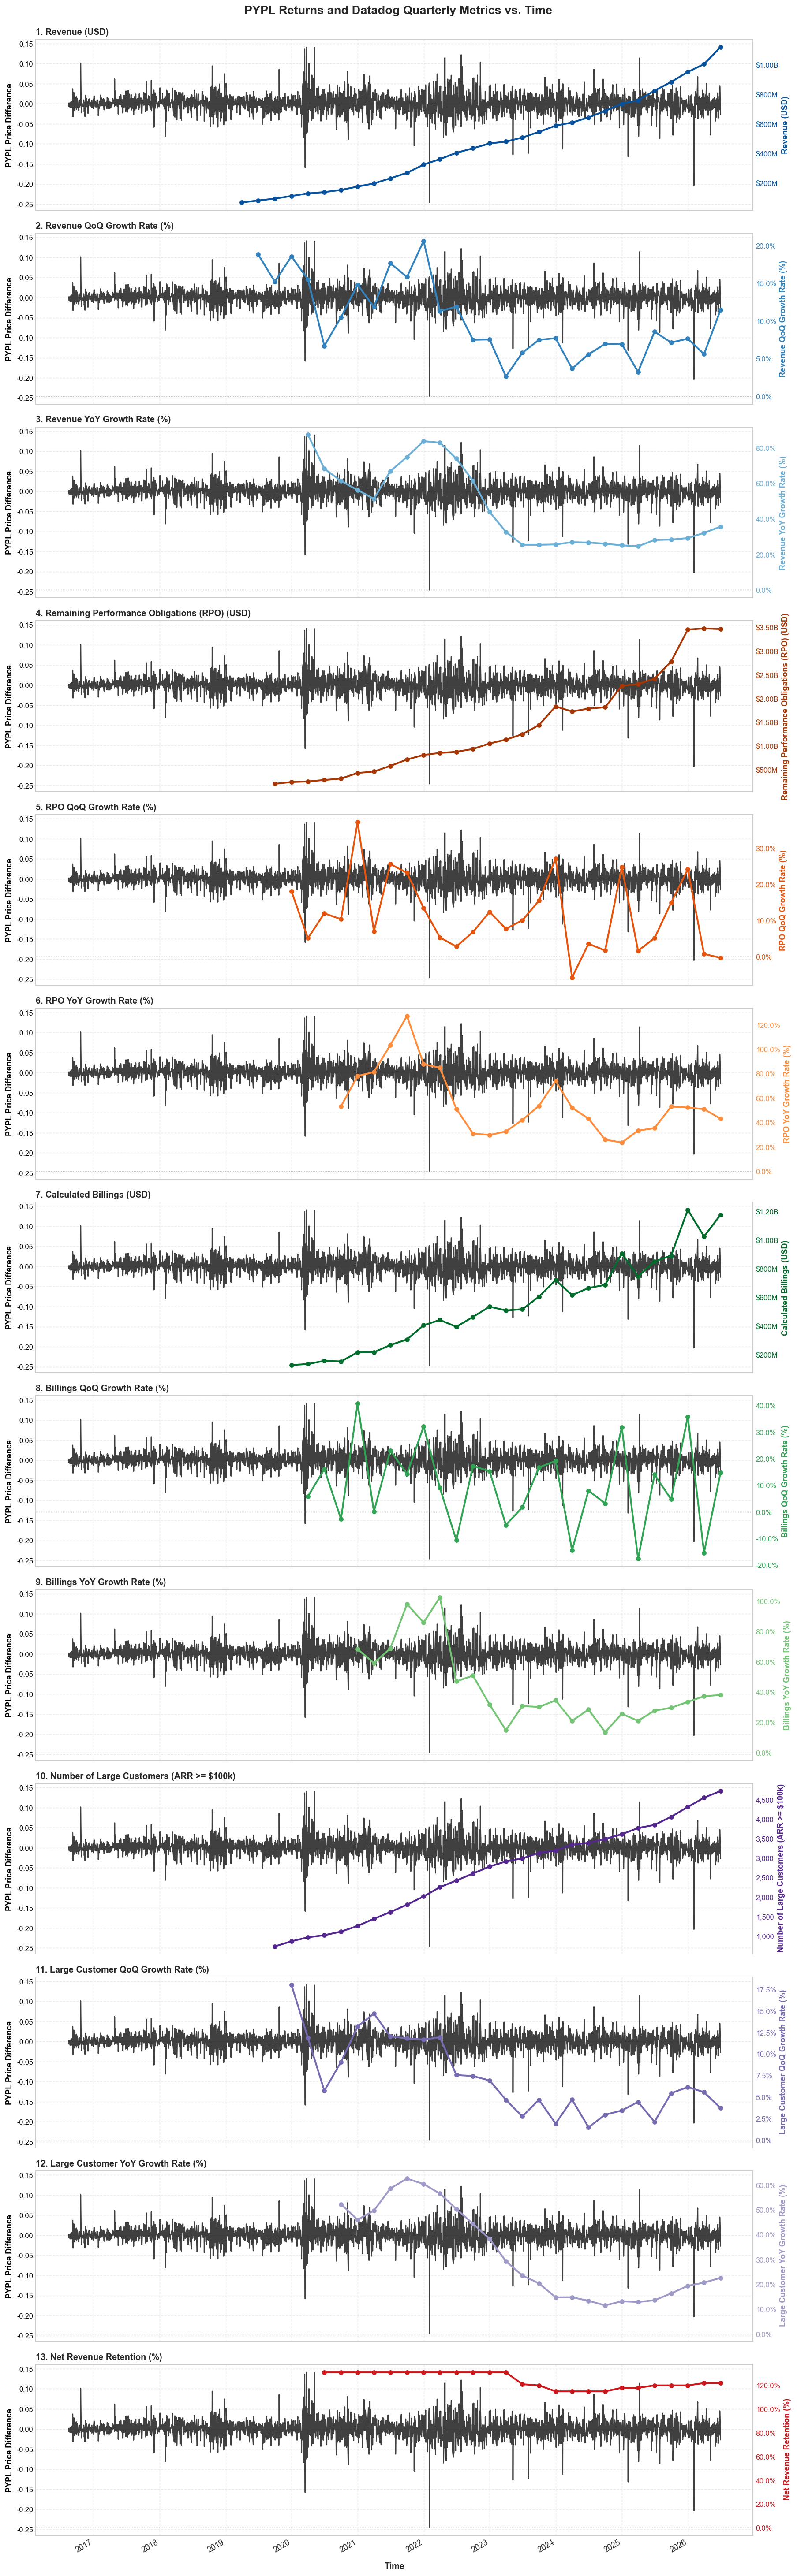

In [177]:
fig, axes = plt.subplots(len(metric_configs), 1, figsize=(14, 45), sharex=True)

for idx, cfg in enumerate(metric_configs):
    ax1 = axes[idx]
    col = cfg['col']
    metric_color = cfg['color']
    
    # Left axis is PYPL Difference
    line1 = ax1.plot(
        s_pypl_returns.index,
        s_pypl_returns.values,
        color=color_altdata,
        linewidth=1.5,
        alpha=0.75
    )
    ax1.set_ylabel('PYPL Price Difference', color=color_altdata, fontsize=10, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_altdata, labelsize=9)
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.2f}'))
    ax1.grid(True, linestyle='--', alpha=0.4)
    
    # Right axis is Quarterly Metric
    ax2 = ax1.twinx()
    
    if col in df_metrics.columns:
        series = df_metrics[col].dropna()
        dates = series.index
        values = series.values
        
        # Scaling and formatting
        if cfg['type'] == 'currency_b':
            plot_values = values / 1e9
            formatter = ticker.FuncFormatter(lambda x, pos: f'${x:.2f}B' if x >= 1 else f'${x*1000:.0f}M')
        elif cfg['type'] == 'pct':
            plot_values = values
            formatter = ticker.FuncFormatter(lambda x, pos: f'{x:.1f}%')
            ax2.axhline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
        elif cfg['type'] == 'count':
            plot_values = values
            formatter = ticker.FuncFormatter(lambda x, pos: f'{int(x):,}')
        else:
            plot_values = values
            formatter = None

        line2 = ax2.plot(
            dates,
            plot_values,
            color=metric_color,
            marker='o',
            markersize=5,
            linewidth=2.2,
            label=cfg['title'][3:]
        )
        ax2.set_ylabel(cfg['title'][3:], color=metric_color, fontsize=10, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor=metric_color, labelsize=9)
        if formatter:
            ax2.yaxis.set_major_formatter(formatter)
        ax2.grid(False)
        
    ax1.set_title(f"{cfg['title']}", fontsize=11, fontweight='bold', loc='left', pad=6)

axes[-1].set_xlabel('Time', fontsize=11, fontweight='bold', labelpad=10)
fig.autofmt_xdate(rotation=30)
plt.suptitle("PYPL Returns and Datadog Quarterly Metrics vs. Time", fontsize=15, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'historical_traj_comparison_pypl_returns.png')
plt.show()

### Source 2: Tech headlines
Use **30-day rolling average** of classification probabilities of tech-related news headlines because individual probabilities are too noisy. 

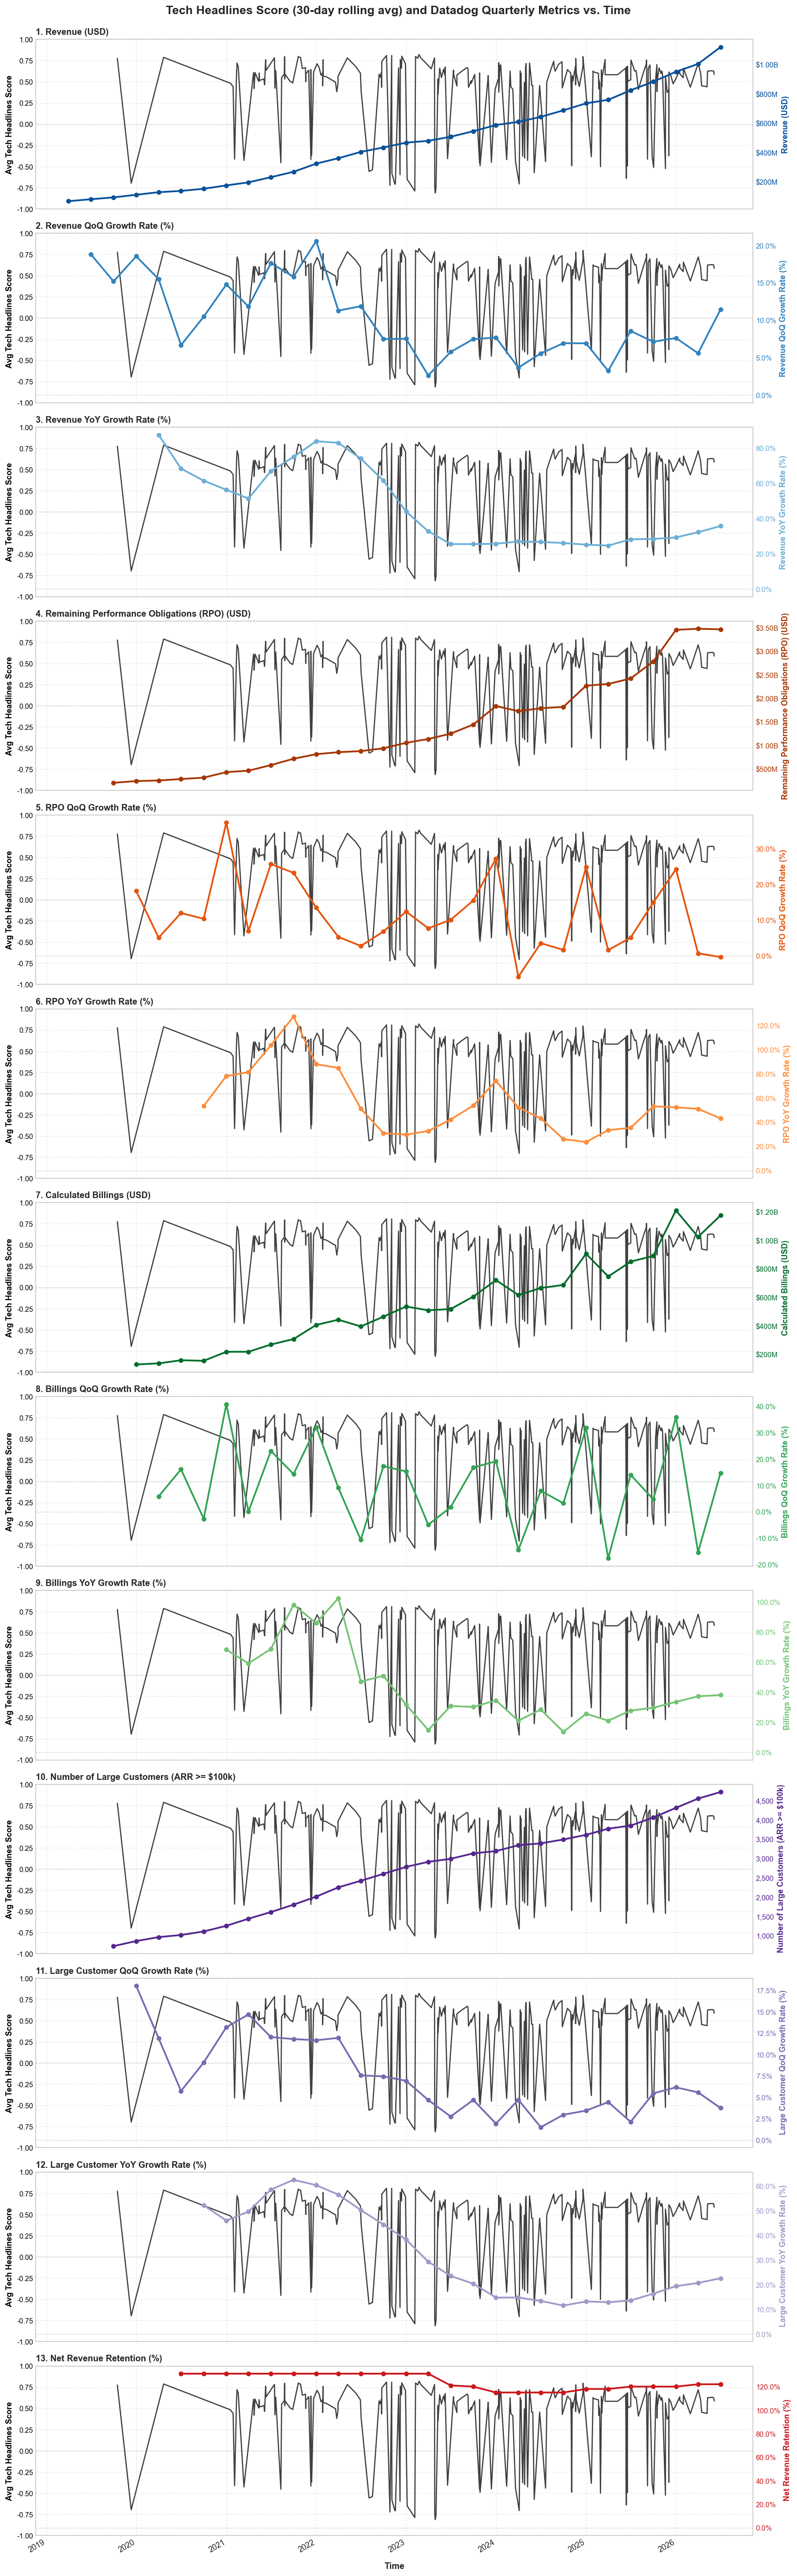

In [8]:
sma_window = 30 # number of days
fig, axes = plt.subplots(len(metric_configs), 1, figsize=(14, 45), sharex=True)

# Create series of simple moving average of classification probabilities
s_tech_headlines_sma = s_tech_headlines.rolling(f'{sma_window}D', min_periods=1).mean()

for idx, cfg in enumerate(metric_configs):
    ax1 = axes[idx]
    col = cfg['col']
    metric_color = cfg['color']
    
    # Left axis is Tech Headlines Score
    line1 = ax1.plot(
        s_tech_headlines.index,
        s_tech_headlines.values,
        color=color_altdata,
        linewidth=1.5,
        alpha=0.75
    )
    ax1.set_ylabel('Avg Tech Headlines Score', color=color_altdata, fontsize=10, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_altdata, labelsize=9)
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x:.2f}'))
    ax1.axhline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
    ax1.grid(True, linestyle='--', alpha=0.4)
    
    # Right axis is Quarterly Metric
    ax2 = ax1.twinx()
    
    if col in df_metrics.columns:
        series = df_metrics[col].dropna()
        dates = series.index
        values = series.values
        
        # Scaling and formatting
        if cfg['type'] == 'currency_b':
            plot_values = values / 1e9
            formatter = ticker.FuncFormatter(lambda x, pos: f'${x:.2f}B' if x >= 1 else f'${x*1000:.0f}M')
        elif cfg['type'] == 'pct':
            plot_values = values
            formatter = ticker.FuncFormatter(lambda x, pos: f'{x:.1f}%')
            ax2.axhline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
        elif cfg['type'] == 'count':
            plot_values = values
            formatter = ticker.FuncFormatter(lambda x, pos: f'{int(x):,}')
        else:
            plot_values = values
            formatter = None

        line2 = ax2.plot(
            dates,
            plot_values,
            color=metric_color,
            marker='o',
            markersize=5,
            linewidth=2.2,
            label=cfg['title'][3:]
        )
        ax2.set_ylabel(cfg['title'][3:], color=metric_color, fontsize=10, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor=metric_color, labelsize=9)
        if formatter:
            ax2.yaxis.set_major_formatter(formatter)
        ax2.grid(False)

    ax1.set_ylim(-1,1)    
    ax1.set_title(f"{cfg['title']}", fontsize=11, fontweight='bold', loc='left', pad=6)

axes[-1].set_xlabel('Time', fontsize=11, fontweight='bold', labelpad=10)
fig.autofmt_xdate(rotation=30)
plt.suptitle(f"Tech Headlines Score ({sma_window}-day rolling avg) and Datadog Quarterly Metrics vs. Time", fontsize=15, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'historical_traj_comparison_tech_headlines_indiv.png')
plt.show()

### Source 3: Datadog product releases
Use **90-day rolling count** of product releases.

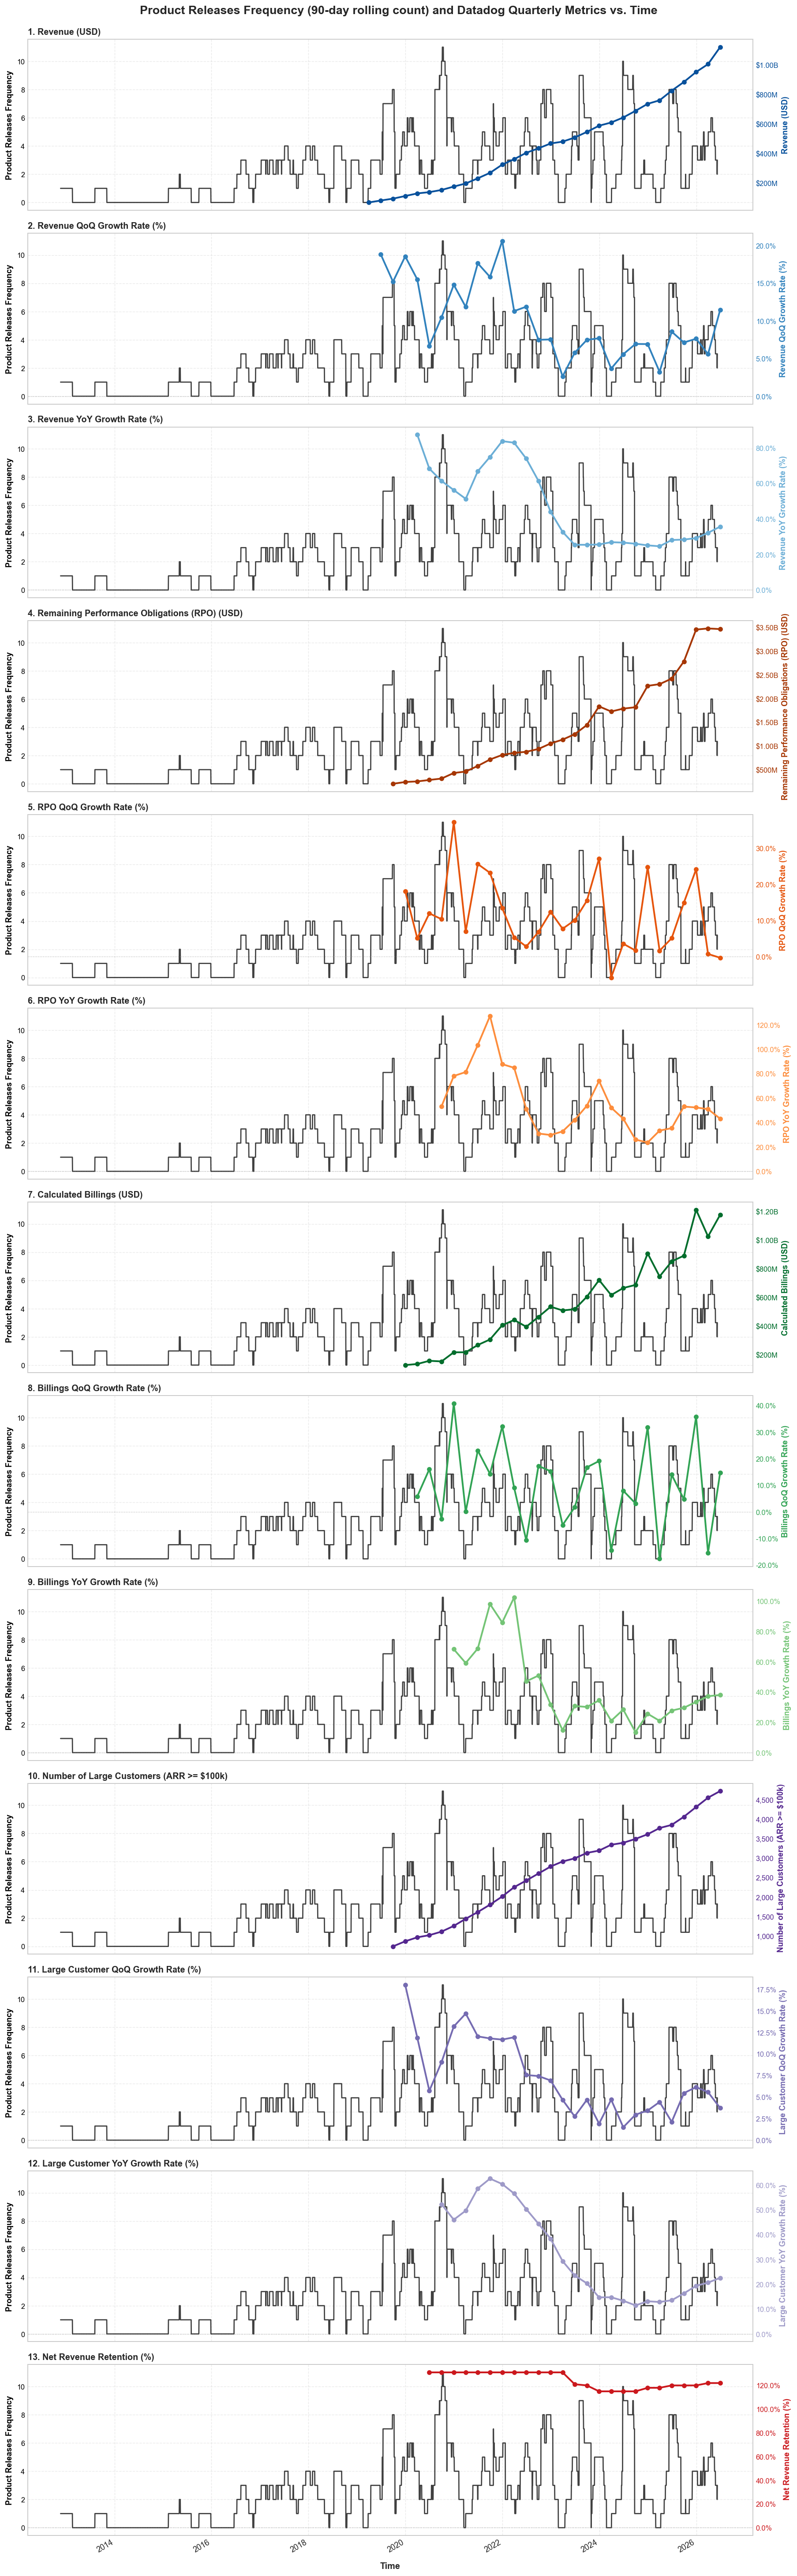

In [9]:
freq_window = 90 # number of days
fig, axes = plt.subplots(len(metric_configs), 1, figsize=(14, 45), sharex=True)

# Create series of rolling count of press releases
s_announcements_freq = s_announcements.resample('D').size().rolling(f'{freq_window}D', min_periods=1).sum()

for idx, cfg in enumerate(metric_configs):
    ax1 = axes[idx]
    col = cfg['col']
    metric_color = cfg['color']
    
    # Left axis is Product Releases Frequency
    line1 = ax1.plot(
        s_announcements_freq.index,
        s_announcements_freq.values,
        color=color_altdata,
        linewidth=1.5,
        alpha=0.75
    )
    ax1.set_ylabel(f'Product Releases Frequency', color=color_altdata, fontsize=10, fontweight='bold')
    ax1.tick_params(axis='y', labelcolor=color_altdata, labelsize=9)
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{int(x)}'))
    ax1.grid(True, linestyle='--', alpha=0.4)
    
    # Right axis is Quarterly Metric
    ax2 = ax1.twinx()
    
    if col in df_metrics.columns:
        series = df_metrics[col].dropna()
        dates = series.index
        values = series.values
        
        # Scaling and formatting
        if cfg['type'] == 'currency_b':
            plot_values = values / 1e9
            formatter = ticker.FuncFormatter(lambda x, pos: f'${x:.2f}B' if x >= 1 else f'${x*1000:.0f}M')
        elif cfg['type'] == 'pct':
            plot_values = values
            formatter = ticker.FuncFormatter(lambda x, pos: f'{x:.1f}%')
            ax2.axhline(0, color='gray', linestyle=':', linewidth=0.8, alpha=0.6)
        elif cfg['type'] == 'count':
            plot_values = values
            formatter = ticker.FuncFormatter(lambda x, pos: f'{int(x):,}')
        else:
            plot_values = values
            formatter = None

        line2 = ax2.plot(
            dates,
            plot_values,
            color=metric_color,
            marker='o',
            markersize=5,
            linewidth=2.2,
            label=cfg['title'][3:]
        )
        ax2.set_ylabel(cfg['title'][3:], color=metric_color, fontsize=10, fontweight='bold')
        ax2.tick_params(axis='y', labelcolor=metric_color, labelsize=9)
        if formatter:
            ax2.yaxis.set_major_formatter(formatter)
        ax2.grid(False)

    ax1.set_title(f"{cfg['title']}", fontsize=11, fontweight='bold', loc='left', pad=6)

axes[-1].set_xlabel('Time', fontsize=11, fontweight='bold', labelpad=10)
fig.autofmt_xdate(rotation=30)
plt.suptitle(f"Product Releases Frequency ({freq_window}-day rolling count) and Datadog Quarterly Metrics vs. Time", fontsize=15, fontweight='bold', y=0.998)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'historical_traj_comparison_announcements_freq.png')
plt.show()